# 02 · 합성 RTLS 스트림 EDA — 전처리 결정의 근거

이 노트북은 `foresight simulate --profile full` 로 만든 합성 공장 RTLS 스트림(200 태그 × 12 h × 10 Hz)을 파이프라인이 처리한 결과를
살펴보고, 전처리·라벨 설계에서 내린 결정의 근거를 숫자로 남긴다.

1. 원시 → 정제 → 2.5 Hz 프레임 → 장면: 각 단계에서 얼마나 줄고 왜 줄었는가 (품질 필터, 리샘플, 이력 규칙)
2. 태그 품질과 빈 안 샘플 수 분포 — `quality_min=30` 이 무엇을 버리는가
3. 작업자·차량의 속도 분포 — 보행자 데이터(ETH/UCY)와 얼마나 다른가 (전이 실험의 배경)
4. 구역별·시간대별 혼잡도와 근접(near-miss) 사건 — 어느 구역이 위험한가
5. 충돌 라벨의 양성 비율 대 d_safe — 평가에서 d_safe 민감도를 함께 싣는 이유

**데이터는 합성이다.** 실제 현장 통계로 읽으면 안 되고, 파이프라인·평가 절차를 검증하는 용도다.

In [1]:
import json, os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl


def _find_root() -> Path:
    if os.environ.get("FORESIGHT_ROOT"):
        return Path(os.environ["FORESIGHT_ROOT"])
    p = Path.cwd()
    while p != p.parent and not (p / "pyproject.toml").exists():
        p = p.parent
    return p


ROOT = _find_root()
RAW = ROOT / "data" / "rtls" / "full" / "raw"
PROC = ROOT / "data" / "rtls" / "full" / "processed"
FRAMES = PROC / "frames_2p5hz"
meta = json.loads((PROC / "pipeline_meta.json").read_text())
manifest = json.loads((RAW / "_manifest.json").read_text())
cfg = manifest["config"]
print("profile:", manifest["profile"], "| tags:", cfg["tags"], f"(workers {manifest['n_workers']}, vehicles {manifest['n_vehicles']})", "| hours:", cfg["hours"], "| hz:", cfg["hz"], "| noise sigma (m):", cfg["noise_sigma_m"])
print("layout:", manifest["layout"])

profile: full | tags: 200 (workers 140, vehicles 60) | hours: 12.0 | hz: 10 | noise sigma (m): 0.15
layout: {'width_m': 120.0, 'height_m': 80.0, 'zone_cell_m': 20.0, 'n_cols': 6, 'n_rows': 4, 'n_zones': 24}


## 1. 단계별 행 수 — 어디서 얼마나 줄었나

In [2]:
stages = [
    ("원시 10 Hz 샘플", meta["rows_raw"]),
    ("정제 후 (quality ≥ 30)", meta["rows_clean"]),
    ("2.5 Hz 프레임 (태그·빈)", meta["rows_frames"]),
]
for split, n_scene in meta["scenes"].items():  # 20 프레임 창 (train 은 stride 4, val/test 는 stride 1)
    stages.append((f"장면 {split} (에이전트 {meta['agents'][split]:,})", n_scene))
prev = None
for name, n in stages:
    ratio = f"  ({100 * n / prev:5.1f}% of prev)" if prev and not name.startswith("장면") else ""
    print(f"{name:34s} {n:>14,}{ratio}")
    prev = n if n else prev
print("\n피크 메모리 (MB):", round(meta["peak_rss_mb"]), "| 단계별 시간 (s):", {k: round(v, 1) for k, v in meta["timings"].items()})

원시 10 Hz 샘플                            85,423,957
정제 후 (quality ≥ 30)                    85,057,196  ( 99.6% of prev)
2.5 Hz 프레임 (태그·빈)                      21,576,189  ( 25.4% of prev)
장면 train (에이전트 3,032,179)                 443,180
장면 val (에이전트 2,596,350)                   378,260
장면 test (에이전트 2,595,497)                  378,943

피크 메모리 (MB): 2292 | 단계별 시간 (s): {'resample_sink': 45.9, 'window_index': 6.5, 'sceneset': 39.0, 'total': 91.5, 'stats': 29.9}


읽는 법: 정제에서 0.4 % 만 빠지고(품질 필터), 10 Hz → 2.5 Hz 리샘플에서 1/4 로 줄며, 장면은 20 프레임 슬라이딩 창이라 프레임 수와
같은 규모다(학습은 stride 4). 메모리 피크는 시간 파티션 처리 덕분에 2.3 GB 에 머문다(`data_pipeline.md` §4).

## 2. 태그 품질과 빈 안 샘플 수 — 품질 필터가 버리는 것

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

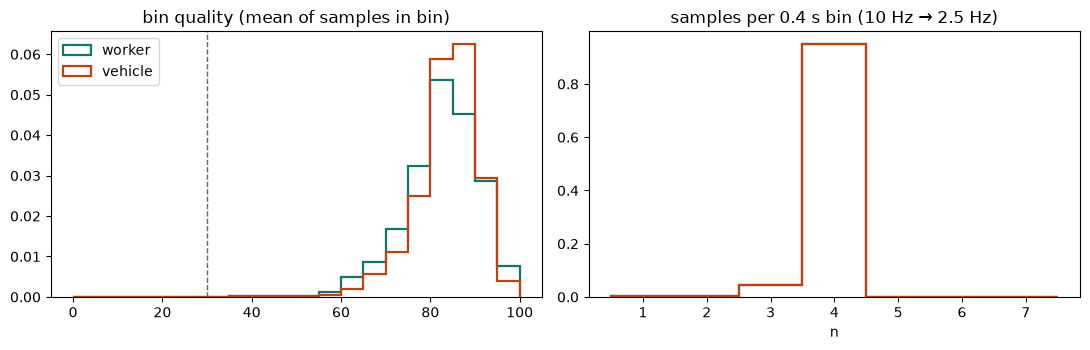

              quality                                                      n  \
                count   mean   std   min   25%   50%   75%    max      count   
agent_type                                                                     
0           1400219.0  82.04  8.34  30.0  78.0  83.0  88.0  100.0  1400219.0   
1            599781.0  83.28  7.14  30.0  80.0  84.0  88.0  100.0   599781.0   

                                                 
            mean   std  min  25%  50%  75%  max  
agent_type                                       
0           3.94  0.27  1.0  4.0  4.0  4.0  4.0  
1           3.94  0.27  1.0  4.0  4.0  4.0  4.0  


In [3]:
con = duckdb.connect()
frames_glob = str(FRAMES / "part=*" / "zone_id=*" / "*.parquet")
q = con.execute(f'''
    SELECT agent_type, quality, n FROM read_parquet('{frames_glob}') USING SAMPLE 2000000 ROWS
''').fetchdf()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for t, name, c in ((0, "worker", "#0f766e"), (1, "vehicle", "#c2410c")):
    sub = q[q.agent_type == t]
    axes[0].hist(sub.quality, bins=np.arange(0, 101, 5), histtype="step", lw=1.6, label=name, color=c, density=True)
    axes[1].hist(sub.n, bins=np.arange(0.5, 8.5, 1), histtype="step", lw=1.6, label=name, color=c, density=True)
axes[0].axvline(30, color="#5f6862", ls="--", lw=1); axes[0].set_title("bin quality (mean of samples in bin)"); axes[0].legend()
axes[1].set_title("samples per 0.4 s bin (10 Hz → 2.5 Hz)"); axes[1].set_xlabel("n")
plt.tight_layout(); plt.show()
print(q.groupby("agent_type")[["quality", "n"]].describe().round(2))

품질은 30 근처에서 잘리고(원시 단계 필터), 빈당 샘플 수는 4 가 대부분이다. 빈에 1~2 개만 있는 경우가 결손의 전조라
`min_bin_samples` 를 파라미터로 두었다(기본 1: 하나라도 있으면 프레임으로 인정).

## 3. 속도 분포 — 보행자 데이터와 무엇이 다른가

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

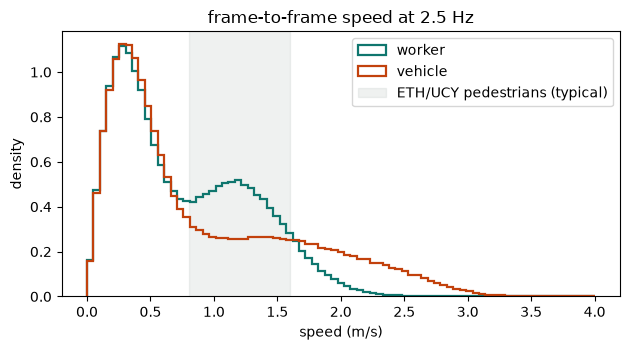

            0.50  0.90  0.99
agent_type                  
0           0.64  1.51  2.01
1           0.61  2.07  2.83


In [4]:
speed = con.execute(f'''
    WITH f AS (
      SELECT tag_id, bin, x, y, agent_type,
             lag(x) OVER (PARTITION BY tag_id ORDER BY bin) AS px,
             lag(y) OVER (PARTITION BY tag_id ORDER BY bin) AS py,
             lag(bin) OVER (PARTITION BY tag_id ORDER BY bin) AS pb
      FROM read_parquet('{frames_glob}')
    )
    SELECT agent_type, sqrt((x-px)*(x-px) + (y-py)*(y-py)) / 0.4 AS v
    FROM f WHERE pb = bin - 1
    USING SAMPLE 1000000 ROWS
''').fetchdf()
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for t, name, c in ((0, "worker", "#0f766e"), (1, "vehicle", "#c2410c")):
    ax.hist(speed[speed.agent_type == t].v, bins=np.linspace(0, 4, 80), histtype="step", lw=1.6, label=name, color=c, density=True)
ax.axvspan(0.8, 1.6, color="#94a3a0", alpha=0.15, label="ETH/UCY pedestrians (typical)")
ax.set_xlabel("speed (m/s)"); ax.set_ylabel("density"); ax.legend(); ax.set_title("frame-to-frame speed at 2.5 Hz")
plt.tight_layout(); plt.show()
print(speed.groupby("agent_type").v.quantile([0.5, 0.9, 0.99]).unstack().round(2))

차량은 보행자보다 2 배 빠르고 정지(0 m/s 근처) 비중도 크다 — ETH/UCY 로 학습한 가중치가 zero-shot 에서 차량을 못 맞추고,
RTLS 로 적응하면 결정적 예측까지 좋아지는 이유다(README §4.5). 0.4 s 사이 0.15 m 의 UWB 노이즈가 0.4 m/s 의 가짜 속도로
보이므로 속도 히스토그램의 0.3~0.5 m/s 봉우리는 정지 태그의 노이즈다 — 학습 입력이 상대 변위라는 점에서 이 노이즈는 그대로 모델에 들어간다.

## 4. 구역별·시간대별 혼잡도와 근접 사건

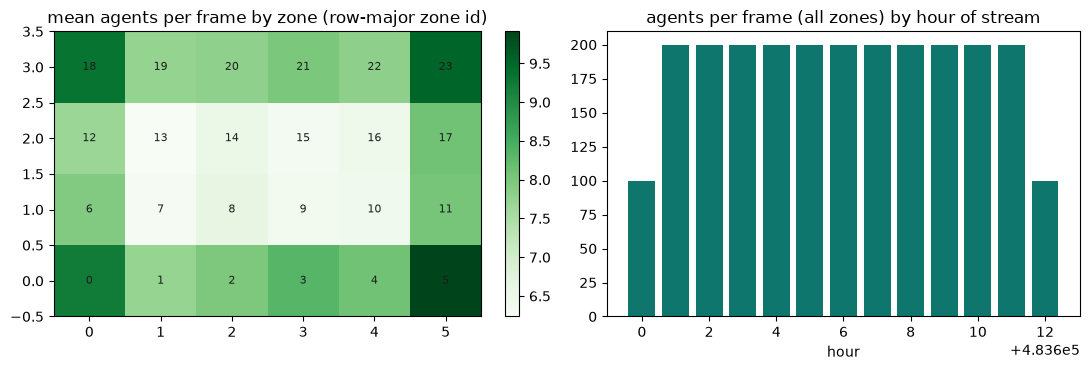

near-miss (simulator truth): 1612 events | 2.239 per vehicle-hour | d_safe 1.0
min_dist quantiles (m): [0.175 0.668 0.969]


In [5]:
occ = con.execute(f'''
    SELECT zone_id, (bin * 0.4 / 3600.0)::INT AS hour, count(*) / 9000.0 AS agents_per_frame
    FROM read_parquet('{frames_glob}')
    GROUP BY 1, 2
''').fetchdf()
layout = manifest["layout"]; ncol, nrow = layout["n_cols"], layout["n_rows"]
grid = np.zeros((nrow, ncol))
for z, g in occ.groupby("zone_id"):
    grid[int(z) // ncol, int(z) % ncol] = g.agents_per_frame.mean()
events = pl.DataFrame(manifest["near_miss"]["events"])
ev_zone = None
if len(events):
    # 사건 좌표가 없으면 작업자 태그의 첫 프레임 구역으로 근사
    ev_zone = events.with_columns(pl.col("ts_ms").cast(pl.Int64))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
im = axes[0].imshow(grid, origin="lower", cmap="Greens")
axes[0].set_title("mean agents per frame by zone (row-major zone id)"); plt.colorbar(im, ax=axes[0], fraction=0.046)
for r in range(nrow):
    for c in range(ncol):
        axes[0].text(c, r, str(r * ncol + c), ha="center", va="center", fontsize=8, color="#1a1f1c")
by_hour = occ.groupby("hour").agents_per_frame.sum()
axes[1].bar(by_hour.index, by_hour.values, color="#0f766e")
axes[1].set_title("agents per frame (all zones) by hour of stream"); axes[1].set_xlabel("hour")
plt.tight_layout(); plt.show()
nm = manifest["near_miss"]
print("near-miss (simulator truth):", nm["count"], "events |", nm["per_vehicle_hour"], "per vehicle-hour | d_safe", nm["d_safe"])
print("min_dist quantiles (m):", np.quantile(events["min_dist"].to_numpy(), [0.1, 0.5, 0.9]).round(3) if len(events) else "n/a")

구역별 혼잡도는 통로 교차점이 많은 안쪽 구역이 높고, 근접 사건(시뮬레이터가 주입한 진실)은 차량-시간당 약 2 건이다.
데모(`foresight demo`)가 "양성이 가장 많은 구역·창"을 고르는 규칙은 이 분포에서 나왔다.

## 5. 충돌 라벨 양성 비율 대 d_safe

 d_safe     pairs  positive  rate %
    0.5   395,837        58    0.01
    1.0   395,781       260    0.07
    1.5   394,013     4,935    1.25
    2.0   384,804    13,669    3.55
    3.0   360,713    25,615    7.10


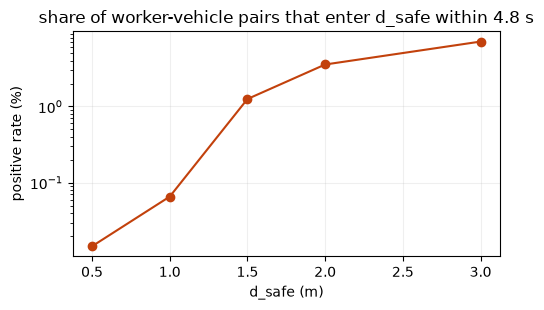

In [6]:
from foresight.data.ethucy import SceneSet
from foresight.eval.collision import pair_labels

test = SceneSet.load(PROC / "test.npz")
keep = np.arange(0, len(test), 10)  # 평가와 같은 1/10 부분 샘플
counts = test.num_agents[keep]; starts = test.scene_index[keep, 0]
sel = np.concatenate([np.arange(s, s + c) for s, c in zip(starts, counts)]); ends = np.cumsum(counts)
sub = SceneSet(pos=test.pos[sel], scene_index=np.stack([ends - counts, ends], 1), meta=[test.meta[i] for i in keep],
               obs_len=test.obs_len, pred_len=test.pred_len, agent_type=test.agent_type[sel])
rows = []
for d in (0.5, 1.0, 1.5, 2.0, 3.0):
    recs = pair_labels(sub, d)
    n_pos = sum(r.label for r in recs)
    rows.append((d, len(recs), n_pos, 100 * n_pos / max(len(recs), 1)))
print(f"{'d_safe':>7} {'pairs':>9} {'positive':>9} {'rate %':>7}")
for d, n, p, r in rows:
    print(f"{d:7.1f} {n:9,} {p:9,} {r:7.2f}")
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot([r[0] for r in rows], [r[3] for r in rows], marker="o", color="#c2410c")
ax.set_xlabel("d_safe (m)"); ax.set_ylabel("positive rate (%)"); ax.set_yscale("log"); ax.grid(alpha=0.2)
ax.set_title("share of worker-vehicle pairs that enter d_safe within 4.8 s")
plt.tight_layout(); plt.show()

d_safe 1 m 에서 양성은 0.07 % 로 극단적 불균형이고, 2 m 에서 3.5 % 로 50 배 늘어난다. 같은 모델이 1 m 에서는 지오펜스에 지고
2 m 에서는 이기는 결과(README §4.5)는 이 불균형과 예측 오차(ADE 0.58 m) 대 d_safe 비율로 설명된다 — 평가에 d_safe 민감도를 반드시 같이 싣는 이유다.